# GPS-Less Localization — Dataset 2: Cleaning, EDA & Feature Engineering
**Project:** Multi-radio fingerprinting (LoRa + BLE + WiFi) with 5 anchor nodes  
**Hardware:** Anchor = LilyGo T-LORA C6 | Receiver = Heltec WiFi LoRa 32  
**Collection window:** 15 seconds per grid point  
**Intervals:** BLE ≈ 200ms, LoRa = 500ms, WiFi = passive scan  

### Changes vs Dataset 1
| Issue in DS1 | Status in DS2 |
|---|---|
| A4 nearly invisible (1.6% of LoRa) | Improved to 3.2% — anchor repositioned |
| 9 points with <2 anchors heard | Fixed — 0 dead points |
| A2 healthy (9.3%) | ⚠️ A2 LoRa collapsed to 0.5% — only 138 LoRa packets across 442 points |

### Rate Feature Design Decisions
| Radio | Rate Feature | Reason |
|-------|-------------|--------|
| BLE   | ❌ Dropped  | Heltec deaf to BLE during 1.5s WiFi scan window — expected count unknowable |
| LoRa  | ✅ Kept     | Dedicated SX1276 radio — listens independently of WiFi/BLE stack |
| WiFi  | ❌ Dropped  | Anchor seq fixed at 6 in firmware — not a real packet counter |

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

VALID_ANCHORS    = ['A1', 'A2', 'A3', 'A4', 'A5']
EXPECTED_LORA_COUNT = 30   # 15s / 500ms
RSSI_FLOOR       = -120.0
SNR_FLOOR        = -20.0

## 1. Load & Inspect Raw Data

In [ ]:
df = pd.read_csv('../../Dataset_2/raw_radio_data.csv')
print(f'Total rows     : {len(df)}')
print(f'Columns        : {df.columns.tolist()}')
print(f'Memory usage   : {df.memory_usage(deep=True).sum() / 1024:.1f} KB')
df.head(10)

Total rows     : 2231
Columns        : ['gps_coords', 'timestamp_ms', 'anchor', 'protocol', 'rssi', 'snr', 'seq']
Memory usage   : 496.8 KB


,gps_coords,timestamp_ms,anchor,protocol,rssi,snr,seq
0,"12.842302,80.153120",10736220,A3,LORA,-115,-7.2500,29653
1,"12.842302,80.153120",10736330,A1,LORA,-119,-12.0000,31381
2,"12.842302,80.153120",10736721,A3,LORA,-107,1.0000,29654
3,"12.842302,80.153120",10737220,A3,LORA,-106,2.0000,29655
4,"12.842302,80.153120",10737512,A1,WIFI,-83,0.0000,6
5,"12.842302,80.153120",10737722,A3,LORA,-111,-5.5000,29656
6,"12.842302,80.153120",10738221,A3,LORA,-115,-8.7500,29657
7,"12.842302,80.153120",10738331,A1,LORA,-120,-13.7500,31385
8,"12.842302,80.153120",10738722,A3,LORA,-109,-5.7500,29658
9,"12.842302,80.153120",10738832,A1,LORA,-112,-8.7500,31386


In [69]:
# Parse GPS coords from "lat,lon" string column
df[['latitude', 'longitude']] = df['gps_coords'].str.split(',', expand=True).astype(float)
df.drop(columns=['gps_coords'], inplace=True)

print('Unique locations (raw):', df[['latitude','longitude']].drop_duplicates().shape[0])
print('\nProtocol distribution:')
print(df['protocol'].value_counts())
print('\nAnchor distribution (raw — includes rogues):')
print(df['anchor'].value_counts().head(20))

Unique locations (raw): 29

Protocol distribution:
protocol
LORA    1860
BLE      219
WIFI     152
Name: count, dtype: int64

Anchor distribution (raw — includes rogues):
anchor
A3        889
A5        691
A1        418
A4        100
A2         90
A27416      7
A12316      7
A3356       5
A14364      4
A13340      4
A53198      3
A63838      2
A52463      2
A21905      2
A30091      1
A47878      1
A60712      1
A14108      1
A12572      1
A15900      1
Name: count, dtype: int64


## 2. Data Cleaning

In [70]:
# ── 2a. Drop rogue / foreign anchors ──────────────────────────────────────────
# Anything not in A1–A5 is external BLE noise (iPhones in iBeacon format, etc.)
rogue = df[~df['anchor'].isin(VALID_ANCHORS)]
print(f'Rogue anchor rows removed : {len(rogue)}')
print(f'Unique rogue IDs          : {rogue["anchor"].nunique()}')
print('Top rogue anchors:')
print(rogue['anchor'].value_counts().head(10))
df = df[df['anchor'].isin(VALID_ANCHORS)].copy()
print(f'\nRows after rogue removal  : {len(df)}')

Rogue anchor rows removed : 43
Unique rogue IDs          : 16
Top rogue anchors:
anchor
A27416    7
A12316    7
A3356     5
A14364    4
A13340    4
A53198    3
A21905    2
A52463    2
A63838    2
A60712    1
Name: count, dtype: int64

Rows after rogue removal  : 2188


In [71]:
# ── 2b. RSSI plausibility filter [-130, -30] dBm ─────────────────────────────
bad_rssi = df[(df['rssi'] < -130) | (df['rssi'] > -30)]
print(f'Out-of-range RSSI rows removed: {len(bad_rssi)}')
if len(bad_rssi) > 0:
    print(bad_rssi[['anchor','protocol','rssi']].describe())
df = df[(df['rssi'] >= -130) & (df['rssi'] <= -30)].copy()

# ── 2c. LoRa SNR plausibility filter [-20, 15] dB ────────────────────────────
lora_bad_snr = df[(df['protocol'] == 'LORA') & ((df['snr'] < -20) | (df['snr'] > 15))]
print(f'Out-of-range LoRa SNR rows removed: {len(lora_bad_snr)}')
df = df[~((df['protocol'] == 'LORA') & ((df['snr'] < -20) | (df['snr'] > 15)))].copy()

print(f'\nClean rows remaining: {len(df)}')

Out-of-range RSSI rows removed: 0
Out-of-range LoRa SNR rows removed: 0

Clean rows remaining: 2188


In [72]:
# ── 2d. GPS coordinate rounding ───────────────────────────────────────────────
# Round to 5 decimal places (~1.1m precision at equator)
# Merges collection points within 1-2m into a single fingerprint
df['latitude']  = df['latitude'].round(5)
df['longitude'] = df['longitude'].round(5)

n_unique = df[['latitude','longitude']].drop_duplicates().shape[0]
print(f'Unique locations after rounding: {n_unique}')

Unique locations after rounding: 29


## 3. EDA — Raw Packet Level

Before building fingerprints, understand the raw signal characteristics of Dataset 2.

In [73]:
# ── 3a. Anchor × Protocol packet count matrix ─────────────────────────────────
pivot = df.groupby(['anchor','protocol']).size().unstack(fill_value=0)
print('Packet count per Anchor × Protocol:')
print(pivot)
print()
print('LoRa share per anchor (%):')
lora_share = (pivot['LORA'] / pivot.sum(axis=1) * 100).round(1)
print(lora_share)

Packet count per Anchor × Protocol:
protocol  BLE  LORA  WIFI
anchor                   
A1         47   329    42
A2         43     8    39
A3         35   822    32
A4         23    60    17
A5         28   641    22

LoRa share per anchor (%):
anchor
A1   78.7000
A2    8.9000
A3   92.5000
A4   60.0000
A5   92.8000
dtype: float64


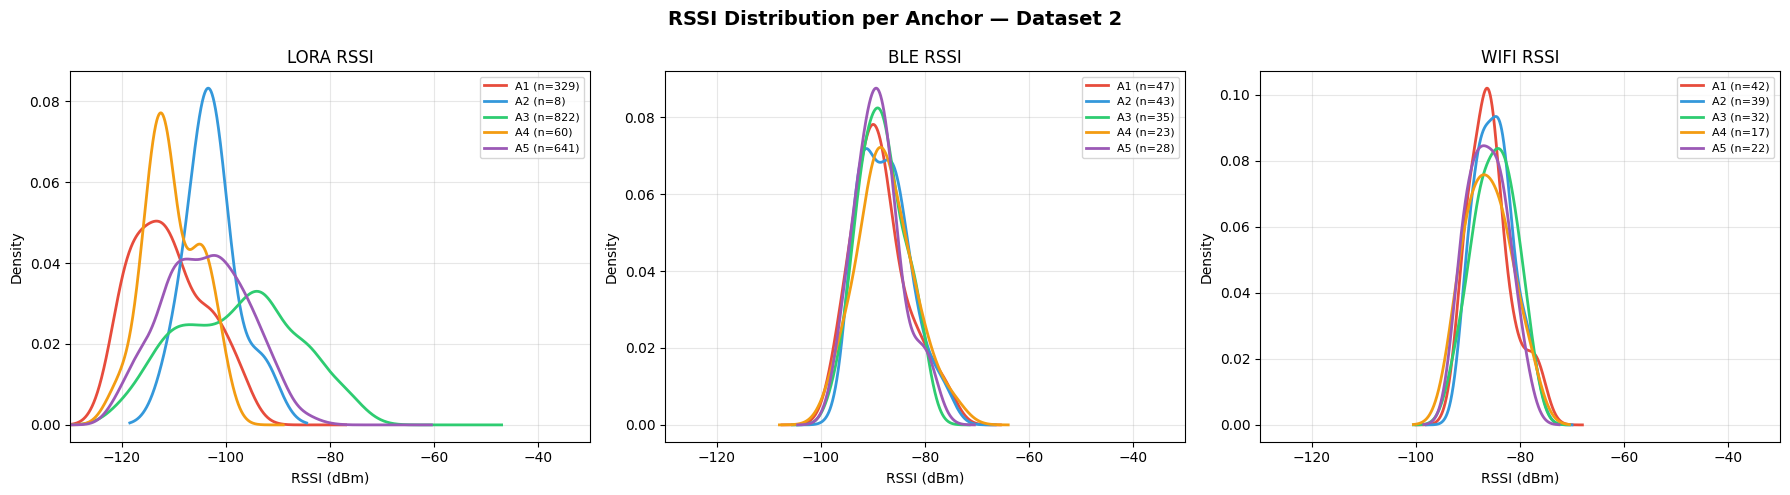

Saved: rssi_distributions_ds2.png


In [74]:
# ── 3b. RSSI distributions per anchor per protocol ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('RSSI Distribution per Anchor — Dataset 2', fontsize=14, fontweight='bold')

palette = {'A1':'#e74c3c','A2':'#3498db','A3':'#2ecc71','A4':'#f39c12','A5':'#9b59b6'}

for ax, proto in zip(axes, ['LORA','BLE','WIFI']):
    sub = df[df['protocol'] == proto]
    for anchor in VALID_ANCHORS:
        data = sub[sub['anchor'] == anchor]['rssi']
        if len(data) > 0:
            data.plot.kde(ax=ax, label=f'{anchor} (n={len(data)})', color=palette[anchor], linewidth=2)
    ax.set_title(f'{proto} RSSI')
    ax.set_xlabel('RSSI (dBm)')
    ax.set_xlim(-130, -30)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
# plt.savefig('rssi_distributions_ds2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: rssi_distributions_ds2.png')

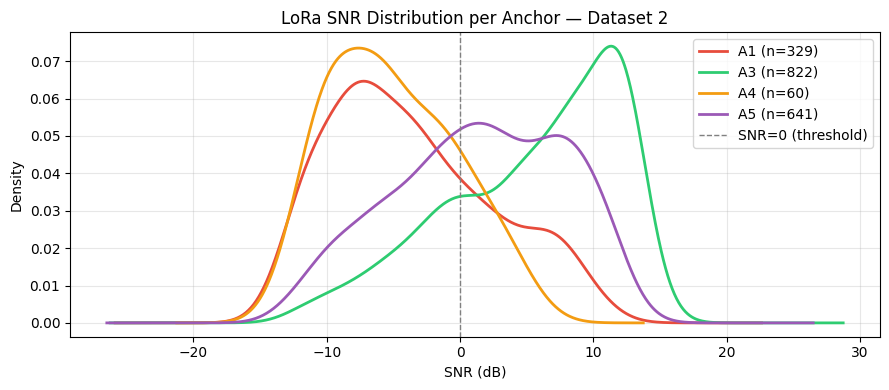

Saved: snr_distributions_ds2.png

LoRa RSSI + SNR stats per anchor:
            rssi                   snr             
            mean     std count    mean    std count
anchor                                             
A1     -111.0300  7.1800   329 -3.6300 6.0700   329
A2     -102.7500  4.8900     8 -2.2800 1.6400     8
A3      -97.7100 11.3200   822  5.5100 6.4300   822
A4     -110.3800  5.2200    60 -5.0800 4.6200    60
A5     -104.0500  8.2000   641  1.4000 6.3500   641


In [75]:
# ── 3c. LoRa SNR distribution per anchor ─────────────────────────────────────
lora_df = df[df['protocol'] == 'LORA']

fig, ax = plt.subplots(figsize=(9, 4))
for anchor in VALID_ANCHORS:
    data = lora_df[lora_df['anchor'] == anchor]['snr']
    if len(data) > 10:
        data.plot.kde(ax=ax, label=f'{anchor} (n={len(data)})', color=palette[anchor], linewidth=2)

ax.axvline(0, color='gray', linestyle='--', linewidth=1, label='SNR=0 (threshold)')
ax.set_title('LoRa SNR Distribution per Anchor — Dataset 2')
ax.set_xlabel('SNR (dB)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
# plt.savefig('snr_distributions_ds2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: snr_distributions_ds2.png')

print('\nLoRa RSSI + SNR stats per anchor:')
print(lora_df.groupby('anchor')[['rssi','snr']].agg(['mean','std','count']).round(2))

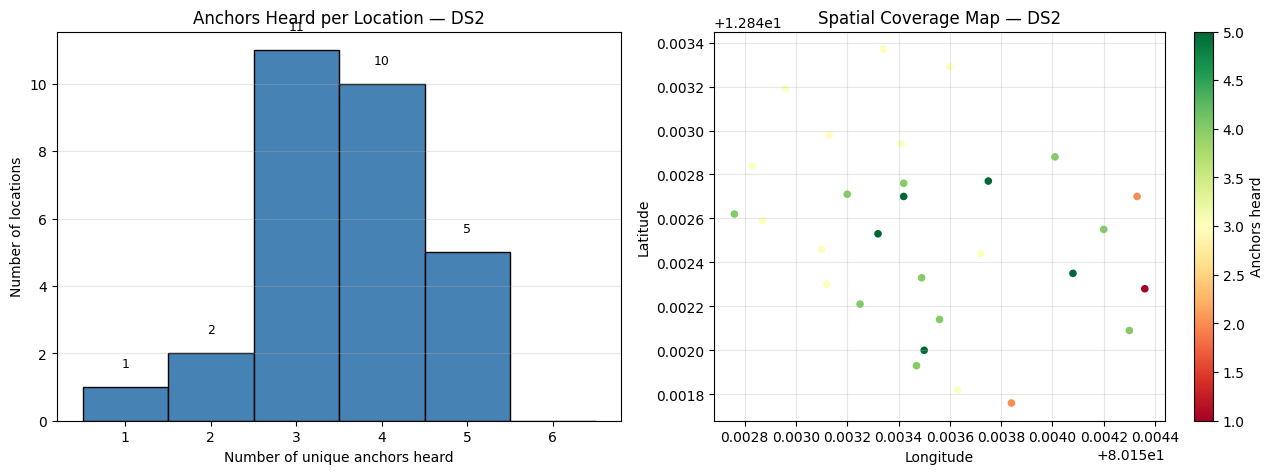

Saved: anchor_coverage_map_ds2.png

Coverage summary:
n_anchors
1     1
2     2
3    11
4    10
5     5
Name: count, dtype: int64

Points with <3 anchors heard: 3
Points with <2 anchors heard: 1


In [76]:
# ── 3d. Anchor coverage per location (how many anchors heard per GPS point) ──
anchors_per_loc = df.groupby(['latitude','longitude'])['anchor'].nunique().reset_index()
anchors_per_loc.columns = ['latitude','longitude','n_anchors']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram
axes[0].hist(anchors_per_loc['n_anchors'], bins=range(1, 8), edgecolor='black',
             color='steelblue', align='left')
axes[0].set_title('Anchors Heard per Location — DS2')
axes[0].set_xlabel('Number of unique anchors heard')
axes[0].set_ylabel('Number of locations')
axes[0].set_xticks(range(1, 7))
for val, cnt in anchors_per_loc['n_anchors'].value_counts().sort_index().items():
    axes[0].text(val, cnt + 0.5, str(cnt), ha='center', va='bottom', fontsize=9)
axes[0].grid(alpha=0.3, axis='y')

# Scatter map colored by anchor coverage
sc = axes[1].scatter(
    anchors_per_loc['longitude'], anchors_per_loc['latitude'],
    c=anchors_per_loc['n_anchors'], cmap='RdYlGn',
    vmin=1, vmax=5, s=30, edgecolors='none'
)
plt.colorbar(sc, ax=axes[1], label='Anchors heard')
axes[1].set_title('Spatial Coverage Map — DS2')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].grid(alpha=0.3)

plt.tight_layout()
# plt.savefig('anchor_coverage_map_ds2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: anchor_coverage_map_ds2.png')

print(f'\nCoverage summary:')
print(anchors_per_loc['n_anchors'].value_counts().sort_index())
print(f'\nPoints with <3 anchors heard: {(anchors_per_loc["n_anchors"] < 3).sum()}')
print(f'Points with <2 anchors heard: {(anchors_per_loc["n_anchors"] < 2).sum()}')

=== A2 LoRa Collapse Analysis ===
A2 LoRa total packets  : 8
A2 LoRa unique locations: 4
A2 BLE  total packets  : 43
A2 WiFi total packets  : 39

A2 LoRa RSSI stats:
count      8.0000
mean    -102.7500
std        4.8917
min     -110.0000
25%     -104.5000
50%     -103.0000
75%     -102.2500
max      -93.0000
Name: rssi, dtype: float64

A2 LoRa SNR stats:
count    8.0000
mean    -2.2812
std      1.6445
min     -5.7500
25%     -2.5625
50%     -2.1250
75%     -1.6250
max      0.0000
Name: snr, dtype: float64


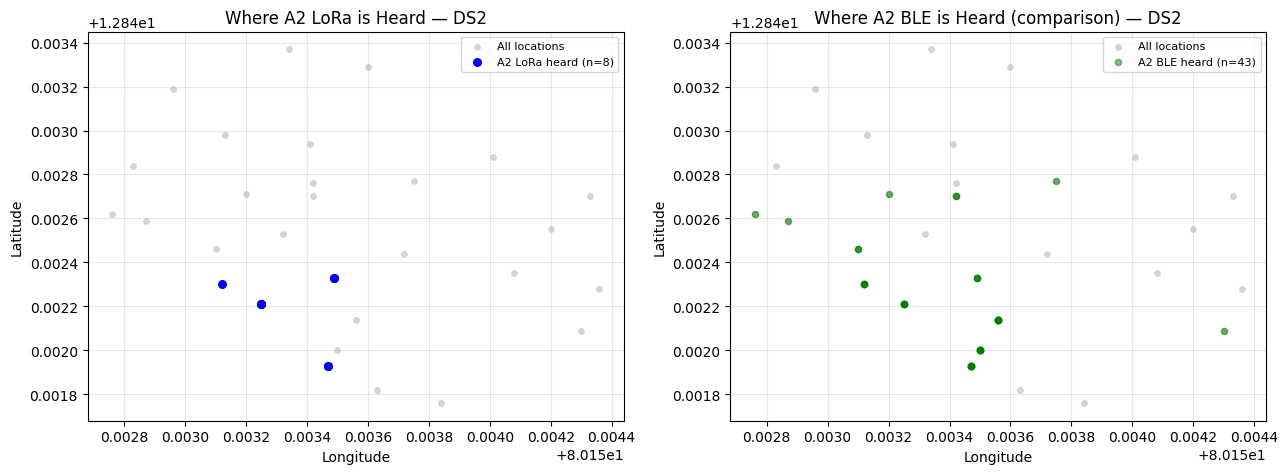

Saved: a2_coverage_analysis_ds2.png


In [77]:
# ── 3e. A2 LoRa collapse analysis ─────────────────────────────────────────────
# A2 dropped from 9.3% (DS1) → 0.5% of LoRa packets in DS2 — investigate spatially
print('=== A2 LoRa Collapse Analysis ===')
a2_lora = df[(df['anchor'] == 'A2') & (df['protocol'] == 'LORA')]
print(f'A2 LoRa total packets  : {len(a2_lora)}')
print(f'A2 LoRa unique locations: {a2_lora[["latitude","longitude"]].drop_duplicates().shape[0]}')
print(f'A2 BLE  total packets  : {len(df[(df["anchor"]=="A2") & (df["protocol"]=="BLE")])}')
print(f'A2 WiFi total packets  : {len(df[(df["anchor"]=="A2") & (df["protocol"]=="WIFI")])}')
print()
if len(a2_lora) > 0:
    print('A2 LoRa RSSI stats:')
    print(a2_lora['rssi'].describe())
    print('\nA2 LoRa SNR stats:')
    print(a2_lora['snr'].describe())

# Spatial plot — where does A2 LoRa get heard?
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# All locations
all_locs = df[['latitude','longitude']].drop_duplicates()
axes[0].scatter(all_locs['longitude'], all_locs['latitude'], c='lightgray', s=15, label='All locations')

# A2 LoRa heard locations
if len(a2_lora) > 0:
    axes[0].scatter(a2_lora['longitude'], a2_lora['latitude'],
                    c='blue', s=30, label=f'A2 LoRa heard (n={len(a2_lora)})', zorder=5)
axes[0].set_title('Where A2 LoRa is Heard — DS2')
axes[0].set_xlabel('Longitude'); axes[0].set_ylabel('Latitude')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

# A2 BLE for comparison (BLE still works)
a2_ble = df[(df['anchor'] == 'A2') & (df['protocol'] == 'BLE')]
axes[1].scatter(all_locs['longitude'], all_locs['latitude'], c='lightgray', s=15, label='All locations')
if len(a2_ble) > 0:
    axes[1].scatter(a2_ble['longitude'], a2_ble['latitude'],
                    c='green', s=20, alpha=0.5, label=f'A2 BLE heard (n={len(a2_ble)})', zorder=5)
axes[1].set_title('Where A2 BLE is Heard (comparison) — DS2')
axes[1].set_xlabel('Longitude'); axes[1].set_ylabel('Latitude')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout()
# plt.savefig('a2_coverage_analysis_ds2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: a2_coverage_analysis_ds2.png')

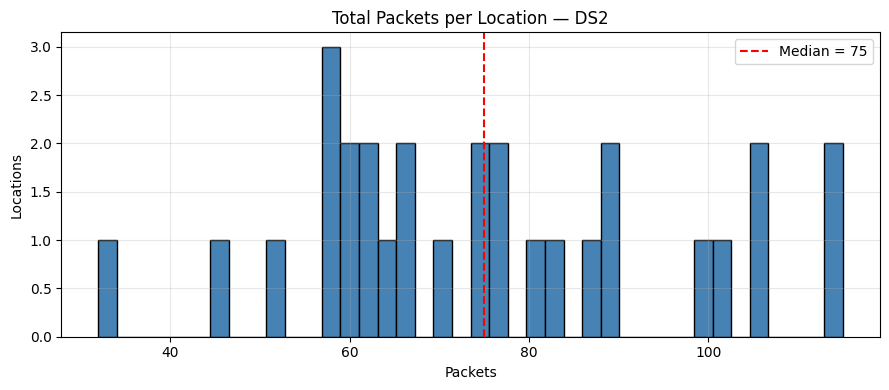

count    29.0000
mean     75.4483
std      20.8542
min      32.0000
25%      61.0000
50%      75.0000
75%      90.0000
max     115.0000
Name: n_packets, dtype: float64


In [78]:
# ── 3f. Packets per location — distribution ───────────────────────────────────
pkt_per_loc = df.groupby(['latitude','longitude']).size().reset_index(name='n_packets')

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(pkt_per_loc['n_packets'], bins=40, edgecolor='black', color='steelblue')
ax.axvline(pkt_per_loc['n_packets'].median(), color='red', linestyle='--',
           label=f'Median = {pkt_per_loc["n_packets"].median():.0f}')
ax.set_title('Total Packets per Location — DS2')
ax.set_xlabel('Packets'); ax.set_ylabel('Locations')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
# plt.savefig('packets_per_location_ds2.png', dpi=150, bbox_inches='tight')
plt.show()

print(pkt_per_loc['n_packets'].describe())

## 4. Feature Extraction Per Location

### Features per anchor:

| Protocol | Features | Count |
|----------|----------|-------|
| BLE  | mean, median, std, min, max, count | 6 |
| LoRa | mean, median, std, min, max, count, rate, snr_mean, snr_std | 9 |
| WiFi | mean, median, std, min, max, count | 6 |

**Per anchor: 21 features × 5 anchors = 105 features total**

### IQR outlier removal  
Before computing stats, RSSI/SNR outliers within each (location, anchor, protocol) group are removed using the 1.5×IQR rule. Reduces multipath spike contamination on mean and std.

In [79]:
def iqr_filter(series, k=1.5):
    """
    Remove values beyond k*IQR from Q1/Q3.
    Falls back to original series if fewer than 4 samples.
    """
    if len(series) < 4:
        return series
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return series[(series >= q1 - k * iqr) & (series <= q3 + k * iqr)]


def extract_features_for_group(group_df, anchor, protocol):
    """
    Extract statistical features from packets of one (location, anchor, protocol).
    Returns a flat dict of feature_name -> value.
    """
    feats  = {}
    prefix = f'{anchor}_{protocol}'

    rssi       = group_df['rssi']
    rssi_clean = iqr_filter(rssi)
    n          = len(rssi_clean)

    feats[f'{prefix}_mean']   = rssi_clean.mean()   if n > 0 else np.nan
    feats[f'{prefix}_median'] = rssi_clean.median() if n > 0 else np.nan
    feats[f'{prefix}_std']    = rssi_clean.std()    if n > 1 else 0.0
    feats[f'{prefix}_min']    = rssi_clean.min()    if n > 0 else np.nan
    feats[f'{prefix}_max']    = rssi_clean.max()    if n > 0 else np.nan
    feats[f'{prefix}_count']  = n

    if protocol == 'LORA':
        feats[f'{prefix}_rate'] = n / EXPECTED_LORA_COUNT
        snr       = group_df['snr']
        snr_clean = iqr_filter(snr)
        feats[f'{prefix}_snr_mean'] = snr_clean.mean() if len(snr_clean) > 0 else np.nan
        feats[f'{prefix}_snr_std']  = snr_clean.std()  if len(snr_clean) > 1 else 0.0

    return feats


print('Feature extractor functions defined.')

Feature extractor functions defined.


In [80]:
MISSING_KEYS = {
    'BLE':  ['mean', 'median', 'std', 'min', 'max', 'count'],
    'LORA': ['mean', 'median', 'std', 'min', 'max', 'count', 'rate', 'snr_mean', 'snr_std'],
    'WIFI': ['mean', 'median', 'std', 'min', 'max', 'count'],
}

locations = df[['latitude', 'longitude']].drop_duplicates().reset_index(drop=True)
print(f'Processing {len(locations)} unique locations...')

all_rows = []
for _, loc in locations.iterrows():
    lat, lon = loc['latitude'], loc['longitude']
    loc_df   = df[(df['latitude'] == lat) & (df['longitude'] == lon)]

    row = {'latitude': lat, 'longitude': lon}

    for anchor in VALID_ANCHORS:
        anchor_df = loc_df[loc_df['anchor'] == anchor]
        for protocol in ['BLE', 'LORA', 'WIFI']:
            proto_df = anchor_df[anchor_df['protocol'] == protocol]
            if len(proto_df) == 0:
                prefix = f'{anchor}_{protocol}'
                for k in MISSING_KEYS[protocol]:
                    row[f'{prefix}_{k}'] = np.nan
            else:
                row.update(extract_features_for_group(proto_df, anchor, protocol))

    all_rows.append(row)

fingerprints = pd.DataFrame(all_rows)
print(f'\nFingerprint table shape: {fingerprints.shape}')
fingerprints.head(3)

Processing 29 unique locations...

Fingerprint table shape: (29, 107)


,latitude,longitude,A1_BLE_mean,A1_BLE_median,A1_BLE_std,A1_BLE_min,A1_BLE_max,A1_BLE_count,A1_LORA_mean,A1_LORA_median,A1_LORA_std,A1_LORA_min,A1_LORA_max,A1_LORA_count,A1_LORA_rate,A1_LORA_snr_mean,A1_LORA_snr_std,A1_WIFI_mean,A1_WIFI_median,A1_WIFI_std,A1_WIFI_min,A1_WIFI_max,A1_WIFI_count,A2_BLE_mean,A2_BLE_median,A2_BLE_std,A2_BLE_min,A2_BLE_max,A2_BLE_count,A2_LORA_mean,A2_LORA_median,A2_LORA_std,A2_LORA_min,A2_LORA_max,A2_LORA_count,A2_LORA_rate,A2_LORA_snr_mean,A2_LORA_snr_std,A2_WIFI_mean,A2_WIFI_median,A2_WIFI_std,A2_WIFI_min,A2_WIFI_max,A2_WIFI_count,A3_BLE_mean,A3_BLE_median,A3_BLE_std,A3_BLE_min,A3_BLE_max,A3_BLE_count,A3_LORA_mean,A3_LORA_median,A3_LORA_std,A3_LORA_min,A3_LORA_max,A3_LORA_count,A3_LORA_rate,A3_LORA_snr_mean,A3_LORA_snr_std,A3_WIFI_mean,A3_WIFI_median,A3_WIFI_std,A3_WIFI_min,A3_WIFI_max,A3_WIFI_count,A4_BLE_mean,A4_BLE_median,A4_BLE_std,A4_BLE_min,A4_BLE_max,A4_BLE_count,A4_LORA_mean,A4_LORA_median,A4_LORA_std,A4_LORA_min,A4_LORA_max,A4_LORA_count,A4_LORA_rate,A4_LORA_snr_mean,A4_LORA_snr_std,A4_WIFI_mean,A4_WIFI_median,A4_WIFI_std,A4_WIFI_min,A4_WIFI_max,A4_WIFI_count,A5_BLE_mean,A5_BLE_median,A5_BLE_std,A5_BLE_min,A5_BLE_max,A5_BLE_count,A5_LORA_mean,A5_LORA_median,A5_LORA_std,A5_LORA_min,A5_LORA_max,A5_LORA_count,A5_LORA_rate,A5_LORA_snr_mean,A5_LORA_snr_std,A5_WIFI_mean,A5_WIFI_median,A5_WIFI_std,A5_WIFI_min,A5_WIFI_max,A5_WIFI_count
0,12.8423,80.1531,-93.0000,-92.0000,1.7321,-95.0000,-92.0000,3.0000,-113.4706,-113.0000,3.2039,-120.0000,-109.0000,17.0000,0.5667,-8.0156,2.1104,-84.5000,-84.5000,2.1213,-86.0000,-83.0000,2.0000,-90.0000,-89.5000,2.4495,-93.0000,-88.0000,4.0000,-110.0000,-110.0000,0.0000,-110.0000,-110.0000,1.0000,0.0333,-5.7500,0.0000,-88.3333,-90.0000,2.8868,-90.0000,-85.0000,3.0000,NaN,NaN,NaN,NaN,NaN,NaN,-101.4643,-101.0000,7.2851,-115,-91,28,0.9333,2.3750,5.9417,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,12.8425,80.1531,-87.3333,-87.0000,0.5774,-88.0000,-87.0000,3.0000,-112.4167,-112.0000,2.7649,-117.0000,-107.0000,24.0000,0.8000,-2.3646,2.3019,-87.3333,-86.0000,3.2146,-91.0000,-85.0000,3.0000,-94.0000,-94.0000,1.4142,-95.0000,-93.0000,2.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-110.5357,-110.5000,3.5327,-119,-104,28,0.9333,0.1250,2.9481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,12.8426,80.1529,-92.2500,-91.5000,3.4034,-97.0000,-89.0000,4.0000,-113.3333,-113.0000,3.9636,-120.0000,-108.0000,24.0000,0.8000,-5.0833,3.8523,-86.0000,-86.0000,1.4142,-87.0000,-85.0000,2.0000,-93.0000,-93.0000,0.0000,-93.0000,-93.0000,1.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-106.8077,-107.0000,5.7898,-117,-97,26,0.8667,1.0288,5.8079,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Missing Value Imputation

When an anchor is not heard at a location, NaN is filled with a meaningful floor value.  
**Do NOT use column median** — "not heard" is itself a strong spatial signal.

| Feature type | Fill value | Reasoning |
|---|---|---|
| RSSI stats (mean, median, min, max) | -120 dBm | Below practical noise floor |
| std | 0.0 | No variation if nothing received |
| count | 0 | Nothing received |
| rate | 0.0 | Zero reception probability |
| snr_mean | -20.0 | Worst-case SNR floor |
| snr_std | 0.0 | No variation if nothing received |

Columns with NaNs: 96

Top 20 NaN counts:
A2_LORA_max         25
A2_LORA_min         25
A2_LORA_std         25
A2_LORA_mean        25
A2_LORA_median      25
A2_LORA_snr_mean    25
A2_LORA_rate        25
A2_LORA_count       25
A2_LORA_snr_std     25
A4_LORA_median      22
A4_LORA_std         22
A4_LORA_min         22
A4_LORA_mean        22
A4_LORA_count       22
A4_LORA_rate        22
A4_LORA_snr_mean    22
A4_LORA_snr_std     22
A4_LORA_max         22
A4_WIFI_std         21
A4_WIFI_mean        21
dtype: int64


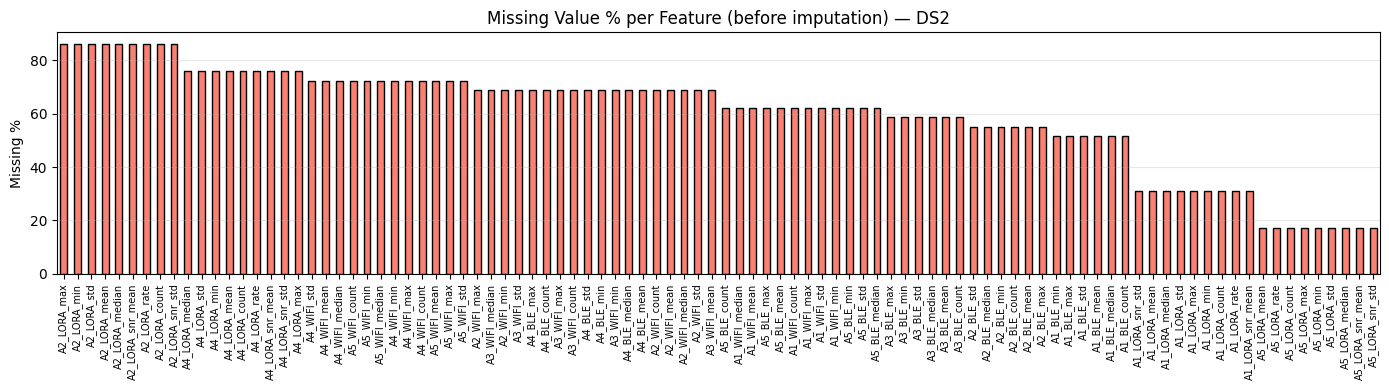

In [81]:
# Show NaN pattern BEFORE imputation
nan_counts = fingerprints.isnull().sum()
nan_counts = nan_counts[nan_counts > 0].sort_values(ascending=False)
print(f'Columns with NaNs: {len(nan_counts)}')
if len(nan_counts) > 0:
    print('\nTop 20 NaN counts:')
    print(nan_counts.head(20))

# Plot NaN heatmap
fig, ax = plt.subplots(figsize=(14, 4))
nan_pct = (fingerprints.isnull().mean() * 100)
nan_pct_feat = nan_pct[nan_pct > 0].sort_values(ascending=False)
if len(nan_pct_feat) > 0:
    nan_pct_feat.plot(kind='bar', ax=ax, color='salmon', edgecolor='black')
    ax.set_title('Missing Value % per Feature (before imputation) — DS2')
    ax.set_ylabel('Missing %'); ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=90, labelsize=7)
    ax.grid(alpha=0.3, axis='y')
    plt.tight_layout()
    # plt.savefig('missing_values_ds2.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No NaN columns to plot.')

In [82]:
# ── A2 LoRa missing rate — special note ───────────────────────────────────────
a2_lora_cols = [c for c in fingerprints.columns if 'A2_LORA' in c]
a2_lora_nan  = fingerprints[a2_lora_cols].isnull().mean() * 100
print('⚠️  A2 LoRa missing rate (%) — anchor may have radio issue in DS2:')
print(a2_lora_nan.round(1))
print()
print('Compare with A1 LoRa missing rate (%):')
a1_lora_cols = [c for c in fingerprints.columns if 'A1_LORA' in c]
print(fingerprints[a1_lora_cols].isnull().mean().mul(100).round(1))

⚠️  A2 LoRa missing rate (%) — anchor may have radio issue in DS2:
A2_LORA_mean       86.2000
A2_LORA_median     86.2000
A2_LORA_std        86.2000
A2_LORA_min        86.2000
A2_LORA_max        86.2000
A2_LORA_count      86.2000
A2_LORA_rate       86.2000
A2_LORA_snr_mean   86.2000
A2_LORA_snr_std    86.2000
dtype: float64

Compare with A1 LoRa missing rate (%):
A1_LORA_mean       31.0000
A1_LORA_median     31.0000
A1_LORA_std        31.0000
A1_LORA_min        31.0000
A1_LORA_max        31.0000
A1_LORA_count      31.0000
A1_LORA_rate       31.0000
A1_LORA_snr_mean   31.0000
A1_LORA_snr_std    31.0000
dtype: float64


In [83]:
# ── Apply imputation ───────────────────────────────────────────────────────────
for col in fingerprints.columns:
    if col in ['latitude', 'longitude']:
        continue
    if '_count' in col or '_rate' in col:
        fingerprints[col] = fingerprints[col].fillna(0.0)
    elif '_std' in col:
        fingerprints[col] = fingerprints[col].fillna(0.0)
    elif 'snr_mean' in col:
        fingerprints[col] = fingerprints[col].fillna(SNR_FLOOR)
    else:
        fingerprints[col] = fingerprints[col].fillna(RSSI_FLOOR)

remaining_nans = fingerprints.isnull().sum().sum()
print(f'Missing values after imputation: {remaining_nans}')
assert remaining_nans == 0, 'Some NaNs remain — check imputation logic!'
print('✅ All NaNs imputed.')

Missing values after imputation: 0
✅ All NaNs imputed.


## 6. Data Quality Checks

In [84]:
# ── 6a. Locations with very sparse LoRa data ──────────────────────────────────
lora_count_cols = [c for c in fingerprints.columns if 'LORA_count' in c]
max_lora        = fingerprints[lora_count_cols].max(axis=1)
sparse_locs     = fingerprints[max_lora < 5]

print(f'Locations with very sparse LoRa (best anchor count < 5): {len(sparse_locs)}')
if len(sparse_locs) > 0:
    print('Consider re-collecting data at these coordinates:')
    print(sparse_locs[['latitude', 'longitude']].to_string())

Locations with very sparse LoRa (best anchor count < 5): 0


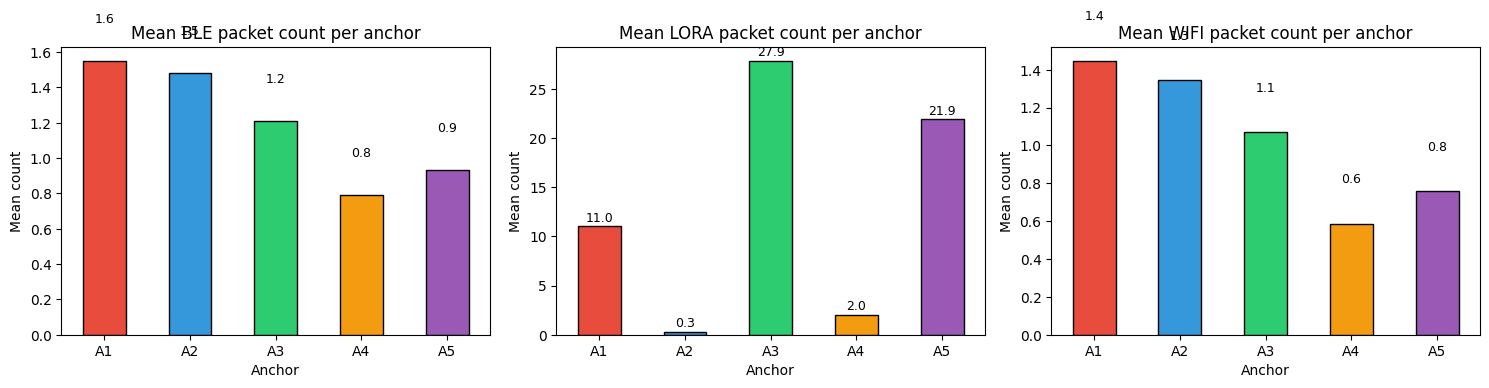

Saved: packet_count_distribution_ds2.png


In [85]:
# ── 6b. Mean packet count per anchor per protocol across all locations ─────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, proto in enumerate(['BLE', 'LORA', 'WIFI']):
    cols  = [c for c in fingerprints.columns if f'_{proto}_count' in c]
    means = fingerprints[cols].mean()
    means.index = [c.split('_')[0] for c in means.index]
    bars = means.plot(kind='bar', ax=axes[i], color=[palette[a] for a in means.index],
                      edgecolor='black')
    axes[i].set_title(f'Mean {proto} packet count per anchor')
    axes[i].set_xlabel('Anchor'); axes[i].set_ylabel('Mean count')
    axes[i].tick_params(axis='x', rotation=0)
    for bar, val in zip(axes[i].patches, means.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                     f'{val:.1f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
# plt.savefig('packet_count_distribution_ds2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: packet_count_distribution_ds2.png')

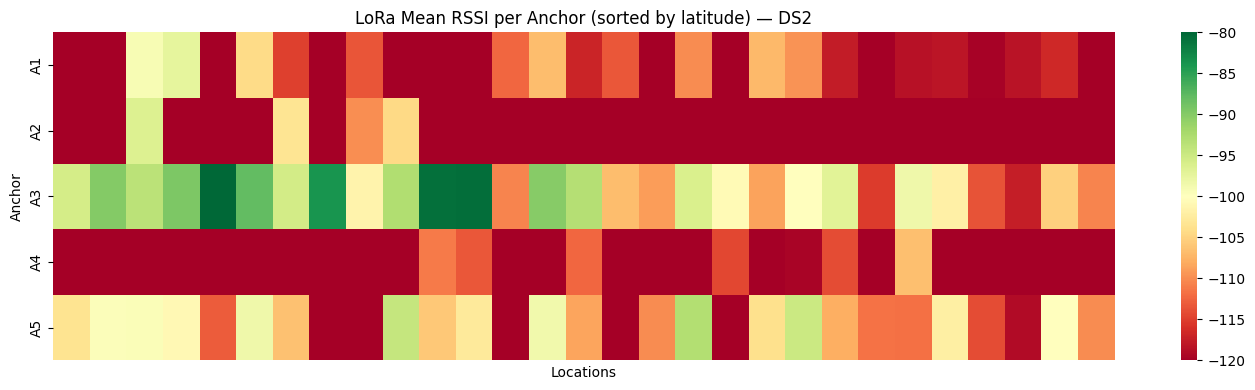

Saved: lora_rssi_heatmap_ds2.png


In [86]:
# ── 6c. LoRa Mean RSSI heatmap (locations × anchors) ─────────────────────────
lora_mean_cols = [c for c in fingerprints.columns if 'LORA_mean' in c and 'snr' not in c]

# Sort locations by latitude for spatial readability
fp_sorted = fingerprints.sort_values('latitude')

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(
    fp_sorted[lora_mean_cols].T,
    cmap='RdYlGn', center=-100, vmin=-120, vmax=-80,
    xticklabels=False,
    yticklabels=[c.replace('_LORA_mean', '') for c in lora_mean_cols],
    ax=ax
)
ax.set_title('LoRa Mean RSSI per Anchor (sorted by latitude) — DS2')
ax.set_xlabel('Locations'); ax.set_ylabel('Anchor')
plt.tight_layout()
# plt.savefig('lora_rssi_heatmap_ds2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: lora_rssi_heatmap_ds2.png')

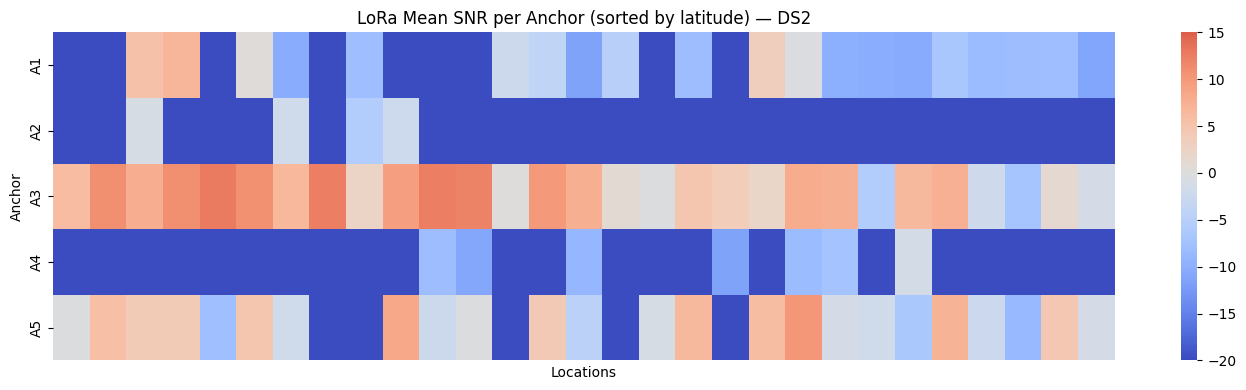

Saved: lora_snr_heatmap_ds2.png


In [87]:
# ── 6d. LoRa Mean SNR heatmap ─────────────────────────────────────────────────
lora_snr_cols = [c for c in fingerprints.columns if 'LORA_snr_mean' in c]
fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(
    fp_sorted[lora_snr_cols].T,
    cmap='coolwarm', center=0, vmin=-20, vmax=15,
    xticklabels=False,
    yticklabels=[c.replace('_LORA_snr_mean', '') for c in lora_snr_cols],
    ax=ax
)
ax.set_title('LoRa Mean SNR per Anchor (sorted by latitude) — DS2')
ax.set_xlabel('Locations'); ax.set_ylabel('Anchor')
plt.tight_layout()
# plt.savefig('lora_snr_heatmap_ds2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: lora_snr_heatmap_ds2.png')

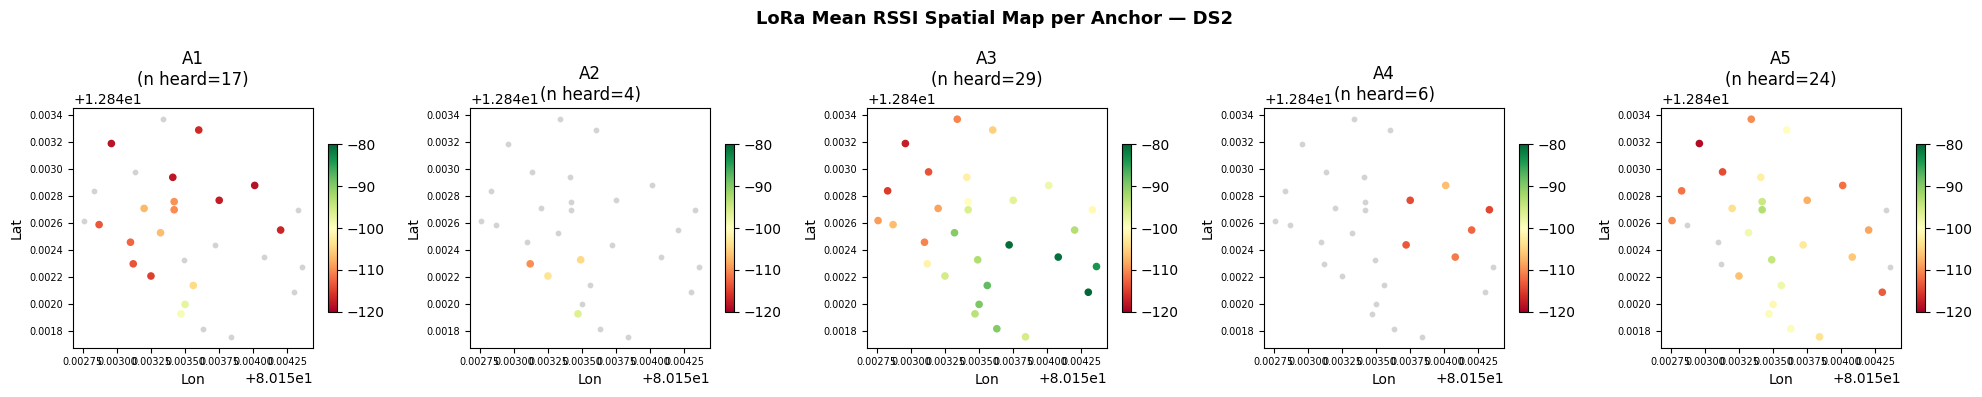

Saved: lora_rssi_spatial_ds2.png


In [88]:
# ── 6e. Spatial RSSI scatter for each anchor (LoRa mean) ─────────────────────
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('LoRa Mean RSSI Spatial Map per Anchor — DS2', fontsize=13, fontweight='bold')

for ax, anchor in zip(axes, VALID_ANCHORS):
    col = f'{anchor}_LORA_mean'
    # Mask imputed floor values for visualization clarity
    mask = fingerprints[col] > RSSI_FLOOR + 1
    sc = ax.scatter(
        fingerprints.loc[mask, 'longitude'],
        fingerprints.loc[mask, 'latitude'],
        c=fingerprints.loc[mask, col],
        cmap='RdYlGn', vmin=-120, vmax=-80, s=20
    )
    ax.scatter(
        fingerprints.loc[~mask, 'longitude'],
        fingerprints.loc[~mask, 'latitude'],
        c='lightgray', s=10, label='Not heard'
    )
    plt.colorbar(sc, ax=ax, shrink=0.7)
    ax.set_title(f'{anchor}\n(n heard={mask.sum()})')
    ax.set_xlabel('Lon'); ax.set_ylabel('Lat')
    ax.tick_params(labelsize=7)

plt.tight_layout()
# plt.savefig('lora_rssi_spatial_ds2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: lora_rssi_spatial_ds2.png')

## 7. Feature Correlation Analysis

**Goal:** Identify which features have strong spatial signal (correlated with lat/lon)  
and which are near-constant (useless for localization).

In [89]:
feature_cols = [c for c in fingerprints.columns if c not in ['latitude', 'longitude']]

corr_lat = fingerprints[feature_cols].corrwith(fingerprints['latitude']).abs().sort_values(ascending=False)
corr_lon = fingerprints[feature_cols].corrwith(fingerprints['longitude']).abs().sort_values(ascending=False)

print('Top 15 features correlated with LATITUDE:')
print(corr_lat.head(15).to_string())
print('\nTop 15 features correlated with LONGITUDE:')
print(corr_lon.head(15).to_string())

Top 15 features correlated with LATITUDE:
A3_LORA_mean       0.6556
A3_LORA_max        0.6536
A3_LORA_median     0.6516
A3_LORA_min        0.6434
A3_LORA_snr_mean   0.6377
A2_BLE_count       0.4998
A1_LORA_min        0.4878
A2_WIFI_count      0.4772
A3_WIFI_min        0.4549
A2_BLE_std         0.4533
A2_WIFI_max        0.4510
A3_WIFI_mean       0.4475
A2_WIFI_std        0.4457
A3_WIFI_median     0.4448
A3_WIFI_max        0.4425

Top 15 features correlated with LONGITUDE:
A3_BLE_max         0.7841
A3_BLE_median      0.7727
A3_BLE_mean        0.7722
A3_BLE_min         0.7561
A3_BLE_count       0.7400
A3_WIFI_max        0.7117
A3_LORA_median     0.7073
A3_WIFI_median     0.7040
A3_LORA_mean       0.7040
A3_WIFI_mean       0.7035
A3_LORA_max        0.7011
A3_WIFI_min        0.6923
A3_LORA_min        0.6812
A3_LORA_snr_mean   0.6712
A3_WIFI_count      0.6588


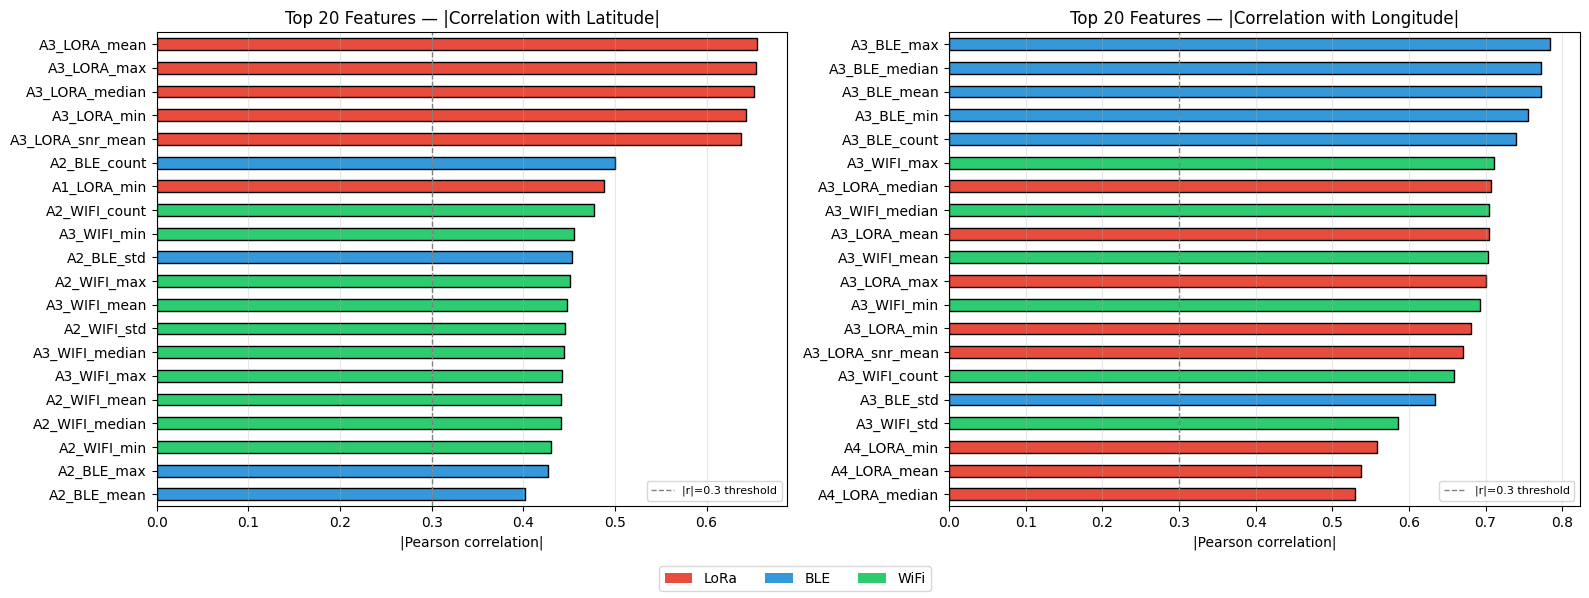

Saved: feature_correlation_ds2.png


In [90]:
# ── Visualise top features correlation ────────────────────────────────────────
n_show = 20
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, corr, label in zip(axes, [corr_lat, corr_lon], ['Latitude', 'Longitude']):
    top = corr.head(n_show)
    colors = ['#e74c3c' if 'LORA' in c else '#3498db' if 'BLE' in c else '#2ecc71' for c in top.index]
    top.plot(kind='barh', ax=ax, color=colors, edgecolor='black')
    ax.set_title(f'Top {n_show} Features — |Correlation with {label}|')
    ax.set_xlabel('|Pearson correlation|')
    ax.invert_yaxis()
    ax.axvline(0.3, color='gray', linestyle='--', linewidth=1, label='|r|=0.3 threshold')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3, axis='x')

# Legend for protocol color
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='LoRa'),
                   Patch(facecolor='#3498db', label='BLE'),
                   Patch(facecolor='#2ecc71', label='WiFi')]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=10)

plt.tight_layout(rect=[0, 0.05, 1, 1])
# plt.savefig('feature_correlation_ds2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: feature_correlation_ds2.png')

In [91]:
# ── Near-zero variance features ───────────────────────────────────────────────
feat_std = fingerprints[feature_cols].std()
low_var  = feat_std[feat_std < 0.01]

print(f'Near-zero variance features ({len(low_var)}) — consider dropping before training:')
if len(low_var) > 0:
    print(low_var.index.tolist())
else:
    print('None found — all features have meaningful variance.')

# ── Medium-variance features — possible candidates to drop ───────────────────
medium_var = feat_std[(feat_std >= 0.01) & (feat_std < 1.0)]
print(f'\nLow-variance features (std < 1.0, {len(medium_var)}):')
print(medium_var.sort_values().to_string())

Near-zero variance features (0) — consider dropping before training:
None found — all features have meaningful variance.

Low-variance features (std < 1.0, 10):
A2_LORA_rate      0.0250
A3_LORA_rate      0.0828
A4_LORA_rate      0.1890
A2_LORA_snr_std   0.3088
A5_LORA_rate      0.3660
A1_LORA_rate      0.3772
A2_LORA_count     0.7510
A3_WIFI_std       0.8599
A2_LORA_std       0.9877
A4_LORA_snr_std   0.9927


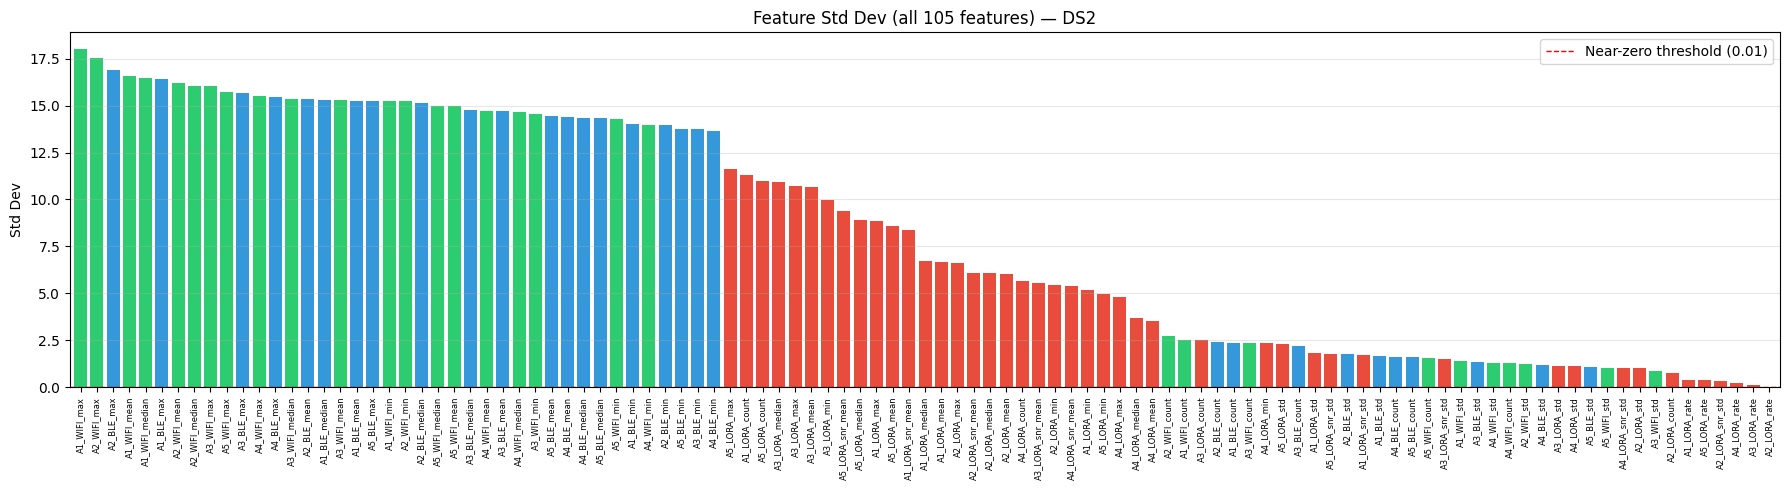

Saved: feature_variance_ds2.png


In [92]:
# ── Feature variance overview — all 105 features ─────────────────────────────
fig, ax = plt.subplots(figsize=(18, 5))
feat_std_sorted = feat_std.sort_values(ascending=False)
colors = ['#e74c3c' if 'LORA' in c else '#3498db' if 'BLE' in c else '#2ecc71'
          for c in feat_std_sorted.index]
feat_std_sorted.plot(kind='bar', ax=ax, color=colors, edgecolor='none', width=0.8)
ax.axhline(0.01, color='red', linestyle='--', linewidth=1, label='Near-zero threshold (0.01)')
ax.set_title('Feature Std Dev (all 105 features) — DS2')
ax.set_ylabel('Std Dev'); ax.set_xlabel('')
ax.tick_params(axis='x', rotation=90, labelsize=6)
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
# plt.savefig('feature_variance_ds2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: feature_variance_ds2.png')

In [93]:
# ── Combined score: max(|corr_lat|, |corr_lon|) × std ── useful signal score ─
max_corr   = pd.concat([corr_lat, corr_lon], axis=1).max(axis=1)
signal_score = (max_corr * feat_std).sort_values(ascending=False)

print('Top 20 features by signal score (|corr| × std):')
print(signal_score.head(20).round(4).to_string())
print('\nBottom 10 features by signal score (least useful):')
print(signal_score.tail(10).round(4).to_string())

Top 20 features by signal score (|corr| × std):
A3_BLE_max       12.2988
A3_WIFI_max      11.4206
A3_BLE_median    11.4195
A3_BLE_mean      11.3531
A3_WIFI_median   10.8151
A3_WIFI_mean     10.7548
A3_BLE_min       10.3865
A3_WIFI_min      10.0827
A2_WIFI_max       7.9063
A3_LORA_median    7.7380
A1_WIFI_max       7.6998
A3_LORA_mean      7.5228
A3_LORA_max       7.5210
A1_WIFI_median    7.2610
A1_WIFI_mean      7.2329
A2_BLE_max        7.2269
A2_WIFI_mean      7.1633
A2_WIFI_median    7.0931
A3_LORA_min       6.7959
A1_WIFI_min       6.7145

Bottom 10 features by signal score (least useful):
A5_LORA_std       0.2207
A5_LORA_snr_std   0.2093
A3_LORA_std       0.2080
A4_WIFI_std       0.2072
A1_LORA_rate      0.1897
A2_LORA_snr_std   0.1038
A4_LORA_rate      0.0643
A5_LORA_rate      0.0602
A3_LORA_rate      0.0335
A2_LORA_rate      0.0081


## 8. Feature-Feature Correlation (Redundancy Check)

Identify highly correlated feature pairs — redundant features can be dropped to reduce model complexity.

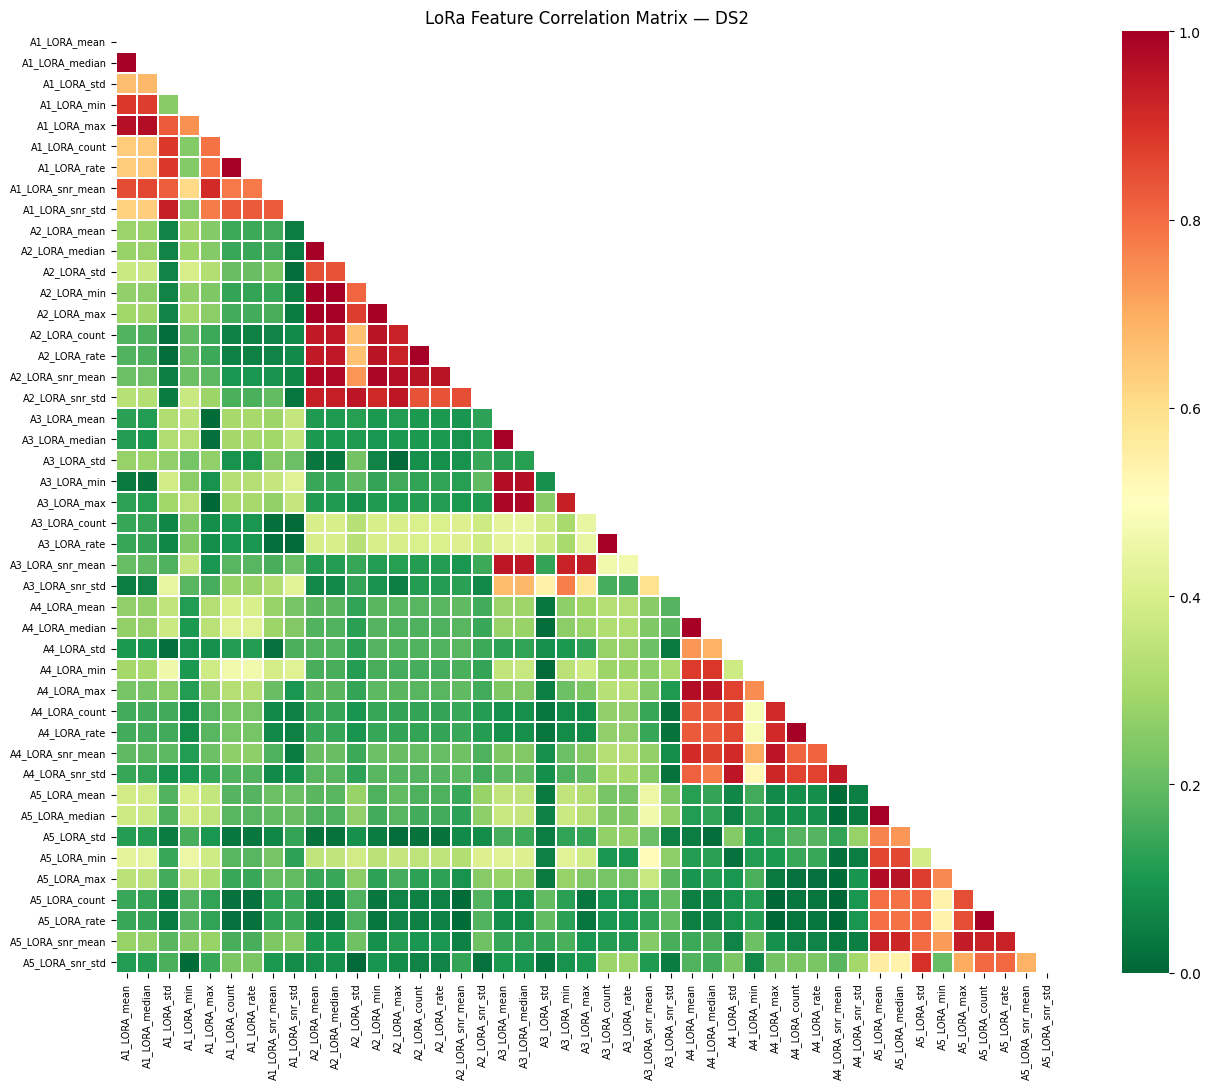

Saved: feature_corr_matrix_ds2.png

Highly correlated LoRa feature pairs (|r| > 0.95): 38
  A4_LORA_count ↔ A4_LORA_rate  : 1.000
  A5_LORA_count ↔ A5_LORA_rate  : 1.000
  A3_LORA_count ↔ A3_LORA_rate  : 1.000
  A1_LORA_count ↔ A1_LORA_rate  : 1.000
  A2_LORA_count ↔ A2_LORA_rate  : 1.000
  A2_LORA_mean ↔ A2_LORA_median  : 1.000
  A1_LORA_mean ↔ A1_LORA_median  : 0.999
  A2_LORA_mean ↔ A2_LORA_max  : 0.998
  A2_LORA_median ↔ A2_LORA_min  : 0.998
  A3_LORA_mean ↔ A3_LORA_median  : 0.998
  A2_LORA_mean ↔ A2_LORA_min  : 0.998
  A2_LORA_median ↔ A2_LORA_max  : 0.998
  A5_LORA_mean ↔ A5_LORA_median  : 0.997
  A4_LORA_mean ↔ A4_LORA_median  : 0.995
  A2_LORA_min ↔ A2_LORA_max  : 0.993


In [94]:
# Compute correlation matrix on LoRa mean features only (primary radio)
lora_feats = [c for c in feature_cols if 'LORA' in c]
corr_matrix = fingerprints[lora_feats].corr().abs()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, cmap='RdYlGn_r', vmin=0, vmax=1,
    square=True, linewidths=0.3, annot=False, ax=ax
)
ax.set_title('LoRa Feature Correlation Matrix — DS2')
ax.tick_params(axis='x', rotation=90, labelsize=7)
ax.tick_params(axis='y', labelsize=7)
plt.tight_layout()
# plt.savefig('feature_corr_matrix_ds2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: feature_corr_matrix_ds2.png')

# Print highly correlated pairs
upper_tri = corr_matrix.where(mask == False)
high_corr = [(col, row, upper_tri.at[row, col])
             for col in upper_tri.columns for row in upper_tri.index
             if upper_tri.at[row, col] > 0.95 and row != col]
high_corr.sort(key=lambda x: -x[2])
print(f'\nHighly correlated LoRa feature pairs (|r| > 0.95): {len(high_corr)}')
for f1, f2, r in high_corr[:15]:
    print(f'  {f1} ↔ {f2}  : {r:.3f}')

## 9. Save Final Dataset

In [95]:
# Reorder columns: labels first, then features sorted by signal score
label_cols   = ['latitude', 'longitude']
feature_cols_sorted = signal_score.index.tolist()  # sorted by signal score descending
fingerprints = fingerprints[label_cols + feature_cols_sorted]

# fingerprints.to_csv('fingerprints_ds2.csv', index=False)

print('=' * 55)
print('Saved: fingerprints_ds2.csv')
print(f'  Rows (locations) : {fingerprints.shape[0]}')
print(f'  Total columns    : {fingerprints.shape[1]}')
print(f'  Labels           : {len(label_cols)}')
print(f'  Features         : {len(feature_cols_sorted)}')
print('=' * 55)

fingerprints.describe().T

Saved: fingerprints_ds2.csv
  Rows (locations) : 29
  Total columns    : 107
  Labels           : 2
  Features         : 105


,count,mean,std,min,25%,50%,75%,max
latitude,29.0000,12.8425,0.0004,12.8418,12.8423,12.8425,12.8428,12.8434
longitude,29.0000,80.1535,0.0005,80.1528,80.1532,80.1535,80.1538,80.1544
A3_BLE_max,29.0000,-107.3448,15.6850,-120.0000,-120.0000,-120.0000,-92.0000,-80.0000
A3_WIFI_max,29.0000,-109.5862,16.0480,-120.0000,-120.0000,-120.0000,-92.0000,-78.0000
A3_BLE_median,29.0000,-107.9828,14.7796,-120.0000,-120.0000,-120.0000,-92.0000,-82.0000
...,...,...,...,...,...,...,...,...
A2_LORA_snr_std,29.0000,0.0960,0.3088,0.0000,0.0000,0.0000,0.0000,1.4142
A4_LORA_rate,29.0000,0.0667,0.1890,0.0000,0.0000,0.0000,0.0000,0.9333
A5_LORA_rate,29.0000,0.7310,0.3660,0.0000,0.6667,0.9333,0.9667,1.0000
A3_LORA_rate,29.0000,0.9299,0.0828,0.6333,0.9000,0.9333,1.0000,1.0000


## 9b. Feature Improvements (Post-Processing)

Apply the improvements discovered during fingerprint analysis. Run this section
**after** the base `fingerprints` table is built and imputed (Section 5).
It produces `fingerprints_improved` — the recommended input for model training.

| Action | Δ Features | Reason |
|--------|-----------|--------|
| Drop all `_median` columns | –15 | \|r(mean, median)\| > 0.995 for all 15 anchor×protocol pairs — pure redundancy |
| Drop `A2_LORA_std`, `A2_WIFI_std`, `A4_WIFI_std` | –3 | >80% of values are the imputed zero — near-constant |
| Add 10 LoRa RSSI diff pairs (all combos of A1–A5) | +10 | Differential ranging; `DIFF_LORA_A1_A3` and `DIFF_LORA_A3_A4` reach \|r\|=0.69 with lat/lon |
| Add 3 BLE diff pairs (A1–A3, A1–A5, A3–A5) | +3 | `DIFF_BLE_A1_A5` reaches \|r\|=0.665 with longitude |
| **Total: 105 → 100 features** | | Fewer columns, stronger top signal |

In [96]:
from itertools import combinations

def apply_feature_improvements(fp, valid_anchors=None, rssi_floor=-120.0):
    """
    Apply post-processing improvements to a base fingerprint DataFrame.

    Steps
    -----
    1. Drop all _median columns   — redundant with _mean (|r| > 0.995)
    2. Drop near-constant _std cols — A2_LORA_std, A2_WIFI_std, A4_WIFI_std
       (>80% imputed zeros because the anchor is barely heard)
    3. Add LoRa RSSI differential features for all C(5,2)=10 anchor pairs
    4. Add BLE  RSSI differential features for 3 highest-signal pairs

    Parameters
    ----------
    fp            : DataFrame output of the feature extraction pipeline
    valid_anchors : list of anchor names (default: A1-A5)
    rssi_floor    : floor value used during imputation (default: -120.0)

    Returns
    -------
    DataFrame with 100 features (down from 105)
    """
    if valid_anchors is None:
        valid_anchors = ['A1', 'A2', 'A3', 'A4', 'A5']

    df = fp.copy()
    label_cols = ['latitude', 'longitude']

    # ── Step 1: Drop _median columns ─────────────────────────────────────
    drop_median = [c for c in df.columns if c.endswith('_median')]
    print(f'Dropping {len(drop_median)} median columns (redundant with mean):')
    print(f'  {drop_median}')
    df.drop(columns=drop_median, inplace=True)

    # ── Step 2: Drop near-constant std columns ────────────────────────────
    # These are anchors that are barely heard — their std is almost always
    # the imputed 0.0, so they carry no spatial information.
    dead_std_candidates = []
    feat_cols = [c for c in df.columns if c not in label_cols]
    for col in feat_cols:
        if col.endswith('_std') and 'snr' not in col:
            zero_ratio = (df[col] == 0.0).mean()
            if zero_ratio > 0.80:
                dead_std_candidates.append((col, zero_ratio))
    drop_dead_std = [c for c, _ in dead_std_candidates]
    print(f'\nDropping {len(drop_dead_std)} near-constant std columns (>80% zeros):')
    for col, ratio in dead_std_candidates:
        print(f'  {col}  ({ratio*100:.1f}% zeros)')
    df.drop(columns=drop_dead_std, inplace=True)

    # ── Step 3: Add LoRa RSSI differential features ───────────────────────
    # DIFF_LORA_Ax_Ay = Ax_LORA_mean - Ay_LORA_mean
    # These encode the relative signal gradient between anchor pairs,
    # which is the core signal used in classical multilateration.
    lora_diff_cols = []
    for a1, a2 in combinations(valid_anchors, 2):
        col_name = f'DIFF_LORA_{a1}_{a2}'
        df[col_name] = df[f'{a1}_LORA_mean'] - df[f'{a2}_LORA_mean']
        lora_diff_cols.append(col_name)
    print(f'\nAdded {len(lora_diff_cols)} LoRa differential features:')
    print(f'  {lora_diff_cols}')

    # ── Step 4: Add BLE RSSI differential features ────────────────────────
    # Only the 3 pairs with highest spatial correlation
    ble_pairs = [('A1', 'A3'), ('A1', 'A5'), ('A3', 'A5')]
    ble_diff_cols = []
    for a1, a2 in ble_pairs:
        col_name = f'DIFF_BLE_{a1}_{a2}'
        df[col_name] = df[f'{a1}_BLE_mean'] - df[f'{a2}_BLE_mean']
        ble_diff_cols.append(col_name)
    print(f'\nAdded {len(ble_diff_cols)} BLE differential features:')
    print(f'  {ble_diff_cols}')

    # ── Summary ───────────────────────────────────────────────────────────
    n_feat = len([c for c in df.columns if c not in label_cols])
    print(f'\n{"="*50}')
    print(f'Features: 105 → {n_feat}')
    print(f'  Dropped : {len(drop_median) + len(drop_dead_std)}')
    print(f'  Added   : {len(lora_diff_cols) + len(ble_diff_cols)}')
    print(f'Shape: {df.shape}')
    print(f'NaNs : {df.isnull().sum().sum()}')
    print(f'{"="*50}')
    return df


# ── Apply and verify ──────────────────────────────────────────────────────
fingerprints_improved = apply_feature_improvements(fingerprints)

# Quick correlation check — confirm diff features rank highly
feat_cols_imp = [c for c in fingerprints_improved.columns
                 if c not in ['latitude', 'longitude']]
corr_lat_imp = fingerprints_improved[feat_cols_imp].corrwith(
    fingerprints_improved['latitude']).abs().sort_values(ascending=False)
corr_lon_imp = fingerprints_improved[feat_cols_imp].corrwith(
    fingerprints_improved['longitude']).abs().sort_values(ascending=False)

print('\nTop 10 features (improved set) — |corr with latitude|:')
print(corr_lat_imp.head(10).round(3))
print('\nTop 10 features (improved set) — |corr with longitude|:')
print(corr_lon_imp.head(10).round(3))

Dropping 15 median columns (redundant with mean):
  ['A3_BLE_median', 'A3_WIFI_median', 'A3_LORA_median', 'A1_WIFI_median', 'A2_WIFI_median', 'A2_BLE_median', 'A1_BLE_median', 'A5_BLE_median', 'A5_WIFI_median', 'A4_WIFI_median', 'A4_BLE_median', 'A2_LORA_median', 'A1_LORA_median', 'A4_LORA_median', 'A5_LORA_median']

Dropping 5 near-constant std columns (>80% zeros):
  A3_WIFI_std  (82.8% zeros)
  A4_BLE_std  (82.8% zeros)
  A2_LORA_std  (89.7% zeros)
  A5_WIFI_std  (82.8% zeros)
  A4_WIFI_std  (86.2% zeros)

Added 10 LoRa differential features:
  ['DIFF_LORA_A1_A2', 'DIFF_LORA_A1_A3', 'DIFF_LORA_A1_A4', 'DIFF_LORA_A1_A5', 'DIFF_LORA_A2_A3', 'DIFF_LORA_A2_A4', 'DIFF_LORA_A2_A5', 'DIFF_LORA_A3_A4', 'DIFF_LORA_A3_A5', 'DIFF_LORA_A4_A5']

Added 3 BLE differential features:
  ['DIFF_BLE_A1_A3', 'DIFF_BLE_A1_A5', 'DIFF_BLE_A3_A5']

Features: 105 → 98
  Dropped : 20
  Added   : 13
Shape: (29, 100)
NaNs : 0

Top 10 features (improved set) — |corr with latitude|:
DIFF_LORA_A3_A4    0.7230
A3_L

In [ ]:
# ── Save improved fingerprints ────────────────────────────────────────────
# Reorder: labels first, then features sorted by max(|corr_lat|, |corr_lon|) × std
label_cols = ['latitude', 'longitude']
feat_cols_imp = [c for c in fingerprints_improved.columns if c not in label_cols]

feat_std_imp  = fingerprints_improved[feat_cols_imp].std()
max_corr_imp  = pd.concat([corr_lat_imp, corr_lon_imp], axis=1).max(axis=1)
signal_score_imp = (max_corr_imp * feat_std_imp).sort_values(ascending=False)
feat_cols_sorted_imp = signal_score_imp.index.tolist()

fingerprints_improved = fingerprints_improved[label_cols + feat_cols_sorted_imp]
fingerprints_improved.to_csv('fingerprints_ds2.csv', index=False)


In [ ]:
# Also save the feature column list — needed for inference pipeline
import pandas as pd
pd.Series(feat_cols_sorted_imp).to_csv('feature_columns.csv',
                                        index=False, header=['feature'])

print('=' * 55)
print('Saved: fingerprints_ds2_improved.csv')
print(f'  Rows     : {fingerprints_improved.shape[0]}')
print(f'  Columns  : {fingerprints_improved.shape[1]}')
print(f'  Features : {len(feat_cols_sorted_imp)}')
print('Saved: feature_columns_improved.csv')
print('=' * 55)
fingerprints_improved.describe().T

## 10. Feature Set Summary

In [98]:
print('=== FEATURE SET SUMMARY — DATASET 2 ===')
print(f'Total features: {len(feature_cols_sorted)}\n')
for anchor in VALID_ANCHORS:
    acols = [c for c in feature_cols_sorted if c.startswith(anchor + '_')]
    print(f'{anchor}: {len(acols)} features')
    for proto in ['BLE', 'LORA', 'WIFI']:
        pcols = [c for c in acols if f'_{proto}_' in c]
        print(f'  {proto}: {pcols}')

print('\n=== A2 LoRa HEALTH WARNING ===')
a2_lora_miss = (fingerprints['A2_LORA_count'] == 0).mean() * 100
print(f'A2 LoRa is absent at {a2_lora_miss:.1f}% of locations.')
print('A2_LORA_* features will mostly carry imputed floor values.')
print('Tree models handle this gracefully; KNN/MLP may need A2_LORA dropped.')

=== FEATURE SET SUMMARY — DATASET 2 ===
Total features: 105

A1: 21 features
  BLE: ['A1_BLE_max', 'A1_BLE_median', 'A1_BLE_mean', 'A1_BLE_min', 'A1_BLE_count', 'A1_BLE_std']
  LORA: ['A1_LORA_count', 'A1_LORA_snr_mean', 'A1_LORA_max', 'A1_LORA_min', 'A1_LORA_mean', 'A1_LORA_median', 'A1_LORA_std', 'A1_LORA_snr_std', 'A1_LORA_rate']
  WIFI: ['A1_WIFI_max', 'A1_WIFI_median', 'A1_WIFI_mean', 'A1_WIFI_min', 'A1_WIFI_count', 'A1_WIFI_std']
A2: 21 features
  BLE: ['A2_BLE_max', 'A2_BLE_mean', 'A2_BLE_median', 'A2_BLE_min', 'A2_BLE_count', 'A2_BLE_std']
  LORA: ['A2_LORA_max', 'A2_LORA_median', 'A2_LORA_mean', 'A2_LORA_snr_mean', 'A2_LORA_min', 'A2_LORA_std', 'A2_LORA_count', 'A2_LORA_snr_std', 'A2_LORA_rate']
  WIFI: ['A2_WIFI_max', 'A2_WIFI_mean', 'A2_WIFI_median', 'A2_WIFI_min', 'A2_WIFI_count', 'A2_WIFI_std']
A3: 21 features
  BLE: ['A3_BLE_max', 'A3_BLE_median', 'A3_BLE_mean', 'A3_BLE_min', 'A3_BLE_count', 'A3_BLE_std']
  LORA: ['A3_LORA_median', 'A3_LORA_mean', 'A3_LORA_max', 'A3_LORA_

---
## Notes for Model Training

1. **Recommended models (in order):** Random Forest → XGBoost → KNN (k=3–5). Start with RF for a quick baseline and feature importances.
2. **Target:** Predict `[latitude, longitude]` jointly — use `MultiOutputRegressor` or native multi-output support.
3. **Evaluation metric:** Haversine distance error in meters, NOT raw MSE on lat/lon. Target <10m MAE for a 130m area.
4. **Feature scaling:** Use `StandardScaler` before KNN or MLP. Tree-based models (RF, XGBoost) do not need scaling.
5. **Do NOT use random train/test split** — nearby grid points have near-identical fingerprints and will leak. Use spatial K-Fold or your separately collected test data.
6. **LoRa SNR is your strongest outdoor feature** — never drop it even if raw Pearson correlation looks moderate.
7. **A2 LoRa in DS2** — consider two model variants: one with all 105 features, one with A2_LORA features dropped. Compare test error.
8. **Missing anchor at inference:** Apply the same floor values (RSSI=-120, SNR=-20, count=0, rate=0).